# Finding an area of interest

In [1]:
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cm
from swot_analysis import plotting

In [16]:
#Reading a single file
if True:
    data_dir = '/Users/zoecas/Documents/data/'
    filename_basic = 'SWOT_L2_LR_SSH_Basic_048_082_20260330T182039_20260330T191111_PID0_01.nc'
    filename_unsmooth = 'SWOT_L2_LR_SSH_Unsmoothed_048_082_20260330T182037_20260330T191110_PID0_01.nc'

In [5]:
ds_basic = xr.open_dataset(data_dir+filename_basic)
ds_basic

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-03-31T22:44:56Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       62.410565055945725
    ssha_variance:                                 0.12894538221224572
    references:                                    V1.4.1
    equator_longitude:                             -148.37

In [17]:
ds_unsmooth_left = xr.open_dataset(data_dir+filename_unsmooth, group='left')
ds_unsmooth_right = xr.open_dataset(data_dir+filename_unsmooth, group='right')
ds_unsmooth_left

<xarray.Dataset> Size: 4GB
Dimensions:                                (num_lines: 81546, num_pixels: 240,
                                            num_doppler_miti_lines: 10245,
                                            num_doppler_miti_pixels: 24)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 157MB ...
    longitude                              (num_lines, num_pixels) float64 157MB ...
    latitude_doppler_miti                  (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
    longitude_doppler_miti                 (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
Dimensions without coordinates: num_lines, num_pixels, num_doppler_miti_lines,
                                num_doppler_miti_pixels
Data variables: (12/30)
    time                                   (num_lines) datetime64[ns] 652kB ...
    time_tai                               (num_lines) datetime64[ns] 652kB ...
    latitude_uncert                        (num_lines, num_pixels) float64 157MB ...
    longitude_uncert                       (num_lines, num_pixels) float64 157MB ...
    ssh_karin                              (num_lines, num_pixels) float64 157MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 157MB ...
    ...                                     ...
    volumetric_correlation_uncert          (num_lines, num_pixels) float64 157MB ...
    total_coherence                        (num_lines, num_pixels) float64 157MB ...
    time_doppler_miti                      (num_doppler_miti_lines) datetime64[ns] 82kB ...
    time_tai_doppler_miti                  (num_doppler_miti_lines) datetime64[ns] 82kB ...
    geophysical_doppler_miti               (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
    surface_velocity_doppler_miti          (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
Attributes:
    description:  Unsmoothed SSH measurement data and related information for...

(-180.0, -120.0)

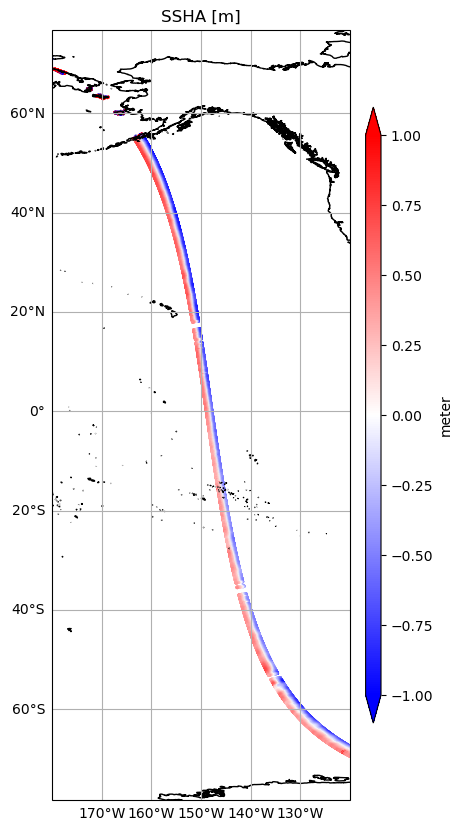

In [9]:
# Basic
title = 'SSHA [m]'
dat = ds_basic.ssha_karin.where(np.isnan(ds_basic.ssha_karin)==False).values
lon = ds_basic.longitude.where(np.isnan(dat)==False).values
lat = ds_basic.latitude.where(np.isnan(dat)==False).values
vmin, vmax = -1,1

lonmax = ((ds_basic.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((ds_basic.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-180,-120)

In [18]:
def zoom(ds,lon_min,lon_max,lat_min,lat_max):
    lon_normalized = (ds["longitude"] + 180) % 360 - 180
    geo_mask = (
        (lon_normalized >= lon_min)
        & (lon_normalized <= lon_max)
        & (ds["latitude"] >= lat_min)
        & (ds["latitude"] <= lat_max)
    )
    return geo_mask
    
lon_min,lon_max = -170,-140 #10,25
lat_min,lat_max = 20,40 #-60,-40
sub_vars = ["ssha_karin","height_cor_xover","latitude","longitude"]


geo_mask = zoom(ds_unsmooth_left[sub_vars],lon_min,lon_max,lat_min,lat_max)
unsmoothl_zoom = ds_unsmooth_left[sub_vars].where(geo_mask, drop=True)

geo_mask = zoom(ds_unsmooth_right[sub_vars],lon_min,lon_max,lat_min,lat_max)
unsmoothr_zoom = ds_unsmooth_right[sub_vars].where(geo_mask, drop=True)

geo_mask = zoom(ds_basic[sub_vars],lon_min,lon_max,lat_min,lat_max)
basic_zoom = ds_basic[sub_vars].where(geo_mask, drop=True)

In [19]:
ssha_basic = (basic_zoom.ssha_karin + basic_zoom.height_cor_xover)
ssha_unsmoothr = (unsmoothr_zoom.ssha_karin + unsmoothr_zoom.height_cor_xover)
ssha_unsmoothl = (unsmoothl_zoom.ssha_karin + unsmoothl_zoom.height_cor_xover)

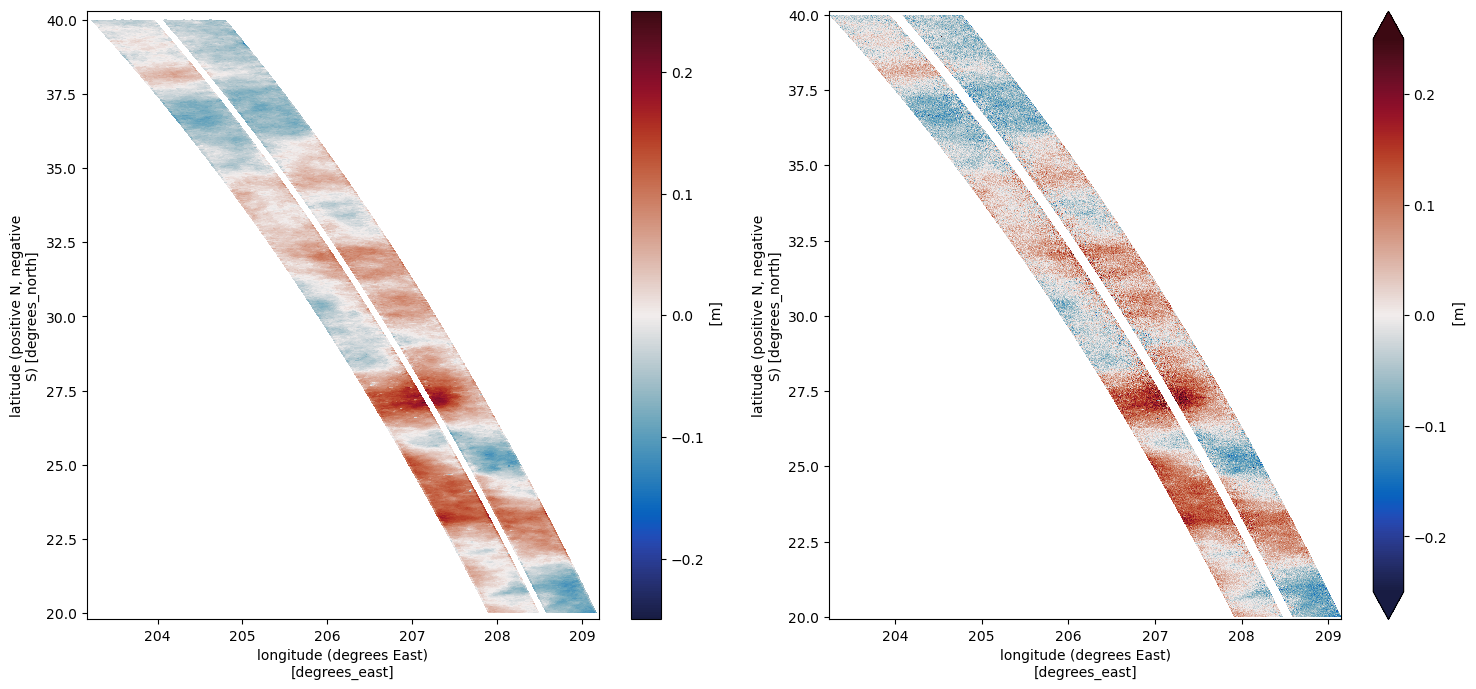

In [23]:
#ssha_basic.plot(x='longitude',y='latitude',vmax=0.25,vmin =-0.25,cmap=cm.cm.balance)
fig,axs = plt.subplots(1,2,figsize=(15,7))
ssha_basic.plot(x='longitude',y='latitude',vmax=0.25,vmin =-0.25,ax=axs[0],cmap=cm.cm.balance)
ssha_unsmoothl.plot(x='longitude',y='latitude',vmax=0.25,vmin =-0.25,ax=axs[1],add_colorbar=False,cmap=cm.cm.balance)
ssha_unsmoothr.plot(x='longitude',y='latitude',vmax=0.25,vmin =-0.25,ax=axs[1],cmap=cm.cm.balance)
#for ax in axs:
#    ax.set_xlim(lon_min,lon_max);
fig.tight_layout()